# Main Figures 2 and 3: robust spectroscopy maps and spectral slices

This notebook uses matched $L=20\,\mu\mathrm{s}$ simulations to compare constant, root-Lorentzian, and echo-root-Lorentzian spectroscopy over 50-MHz-wide and 1-MHz-wide detuning domains. Throughout, detuning is $\Delta/(2\pi)=f_d-f_{01}$, so negative transmon anharmonicity appears on the left. Figure 2 uses a three-state transmon model and shows the $|e\rangle$-population maps; the independently tracked $|f\rangle$ population is stored with the figure data. Figure 3 retains the archived fixed-amplitude two-level root-Lorentzian and echo-root-Lorentzian spectral slices at three peak Rabi frequencies.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'echospec').is_dir())
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.codex_tmp' / 'mpl'))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np

from echospec.figures import FigureVariant, apply_figure_style, save_figure
from echospec.simulation.qutrit import simulate_qutrit_map

VARIANT = FigureVariant.PAPER
SOURCE_PATH = PROJECT_ROOT / 'figures/paper/09_simulated_echo_lorentzian_20us.npz'
CUTOFF = 0.002
# q1 two-photon scans give alpha/(2*pi)=2*(f02/2-f01)=-216 MHz.
ANHARMONICITY_MHZ = -216.0
QUTRIT_MODEL_VERSION = 3
BROAD_SPAN_MHZ = 50.0
NARROW_SPAN_MHZ = 1.0
QUTRIT_DATA_PATH = PROJECT_ROOT / 'figures/paper/02_central_spectroscopy_qutrit.npz'
apply_figure_style(VARIANT)
print(SOURCE_PATH)

/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/09_simulated_echo_lorentzian_20us.npz


In [2]:
with np.load(SOURCE_PATH) as archived:
    duration_us = float(archived['duration_us'])
    cutoffs = np.asarray(archived['cutoffs'], dtype=float)
    detuning_mhz = np.asarray(archived['detuning_mhz'], dtype=float)
    rabi_mhz = np.asarray(archived['rabi_mhz'], dtype=float)
    t1_us = float(archived['t1_us'])
    t_phi_us = float(archived['t_phi_us'])
    archived_maps = {
        'lorentzian': np.asarray(archived[f'lorentzian_cutoff_{CUTOFF:g}'], dtype=float),
        'echo': np.asarray(archived[f'echo_cutoff_{CUTOFF:g}'], dtype=float),
    }

broad_detuning_mhz = np.linspace(-BROAD_SPAN_MHZ / 2, BROAD_SPAN_MHZ / 2, 401)
narrow_detuning_mhz = np.linspace(-NARROW_SPAN_MHZ / 2, NARROW_SPAN_MHZ / 2, 401)

def simulate_view(detuning_grid_mhz, *, steps_per_half):
    results = {}
    for protocol, cutoff, echo in (
        ('constant', None, False),
        ('lorentzian', CUTOFF, False),
        ('echo', CUTOFF, True),
    ):
        results[protocol] = simulate_qutrit_map(
            duration_us=duration_us,
            detuning_mhz=detuning_grid_mhz,
            rabi_mhz=rabi_mhz,
            t1_us=t1_us,
            t_phi_us=t_phi_us,
            anharmonicity_mhz=ANHARMONICITY_MHZ,
            num_steps_per_half=steps_per_half,
            cutoff=cutoff,
            echo=echo,
        )
    return results

def cache_is_current(path):
    if not path.exists():
        return False
    with np.load(path) as cached:
        return (
            int(cached['model_version']) == QUTRIT_MODEL_VERSION
            and str(cached['detuning_convention']) == 'drive_minus_qubit'
            and np.isclose(float(cached['duration_us']), duration_us)
            and np.isclose(float(cached['cutoff']), CUTOFF)
            and np.isclose(float(cached['anharmonicity_mhz']), ANHARMONICITY_MHZ)
            and np.isclose(float(cached['t1_us']), t1_us)
            and np.isclose(float(cached['t_phi_us']), t_phi_us)
            and np.array_equal(cached['rabi_mhz'], rabi_mhz)
            and np.array_equal(cached['broad_detuning_mhz'], broad_detuning_mhz)
            and np.array_equal(cached['narrow_detuning_mhz'], narrow_detuning_mhz)
        )

if cache_is_current(QUTRIT_DATA_PATH):
    with np.load(QUTRIT_DATA_PATH) as cached:
        broad_maps = {name: np.asarray(cached[f'broad_{name}_pe']) for name in ('constant', 'lorentzian', 'echo')}
        narrow_maps = {name: np.asarray(cached[f'narrow_{name}_pe']) for name in ('constant', 'lorentzian', 'echo')}
        broad_leakage = {name: np.asarray(cached[f'broad_{name}_pf']) for name in ('constant', 'lorentzian', 'echo')}
        narrow_leakage = {name: np.asarray(cached[f'narrow_{name}_pf']) for name in ('constant', 'lorentzian', 'echo')}
else:
    broad_results = simulate_view(broad_detuning_mhz, steps_per_half=6400)
    narrow_results = simulate_view(narrow_detuning_mhz, steps_per_half=6400)
    broad_maps = {name: result.excited for name, result in broad_results.items()}
    narrow_maps = {name: result.excited for name, result in narrow_results.items()}
    broad_leakage = {name: result.second_excited for name, result in broad_results.items()}
    narrow_leakage = {name: result.second_excited for name, result in narrow_results.items()}
    np.savez_compressed(
        QUTRIT_DATA_PATH,
        model_version=QUTRIT_MODEL_VERSION,
        detuning_convention='drive_minus_qubit',
        detuning_migration='direct_simulation',
        duration_us=duration_us,
        cutoff=CUTOFF,
        anharmonicity_mhz=ANHARMONICITY_MHZ,
        t1_us=t1_us,
        t_phi_us=t_phi_us,
        rabi_mhz=rabi_mhz,
        broad_detuning_mhz=broad_detuning_mhz,
        narrow_detuning_mhz=narrow_detuning_mhz,
        **{f'broad_{name}_pe': values for name, values in broad_maps.items()},
        **{f'narrow_{name}_pe': values for name, values in narrow_maps.items()},
        **{f'broad_{name}_pf': values for name, values in broad_leakage.items()},
        **{f'narrow_{name}_pf': values for name, values in narrow_leakage.items()},
    )

assert np.isclose(duration_us, 20.0)
assert np.any(np.isclose(cutoffs, CUTOFF))
for protocol in ('constant', 'lorentzian', 'echo'):
    archived_population = archived_maps.get(protocol)
    if archived_population is not None:
        assert archived_population.shape == (rabi_mhz.size, detuning_mhz.size), protocol
    assert broad_maps[protocol].shape == (rabi_mhz.size, broad_detuning_mhz.size)
    assert narrow_maps[protocol].shape == (rabi_mhz.size, narrow_detuning_mhz.size)
    assert np.isfinite(broad_maps[protocol]).all(), protocol
    assert np.isfinite(narrow_maps[protocol]).all(), protocol
    assert broad_maps[protocol].min() >= 0 and broad_maps[protocol].max() <= 1
    assert narrow_maps[protocol].min() >= 0 and narrow_maps[protocol].max() <= 1
    for leakage in (broad_leakage[protocol], narrow_leakage[protocol]):
        assert np.isfinite(leakage).all()
        assert leakage.min() >= 0 and leakage.max() <= 1

effective_t2_us = 1 / (1 / (2 * t1_us) + 1 / t_phi_us)
t2_limit_fwhm_mhz = 1 / (np.pi * effective_t2_us)
print(
    f'L={duration_us:g} us, c={CUTOFF:g}, T1={t1_us:.2f} us, '
    f'Tphi={t_phi_us:.2f} us, T2_eff={effective_t2_us:.3f} us, '
    f'Gamma_T2={1e3 * t2_limit_fwhm_mhz:.3f} kHz, '
    f'three states, anharmonicity/2pi={ANHARMONICITY_MHZ:g} MHz'
)
print('Maximum |f> population:', max(*(values.max() for values in broad_leakage.values()), *(values.max() for values in narrow_leakage.values())))
print(f'Broad detuning grid: {broad_detuning_mhz.size} points from {broad_detuning_mhz.min():g} to {broad_detuning_mhz.max():g} MHz')
print(f'Narrow detuning grid: {narrow_detuning_mhz.size} points from {narrow_detuning_mhz.min():g} to {narrow_detuning_mhz.max():g} MHz')
print(f'Peak-Rabi grid: {rabi_mhz.size} points from {rabi_mhz.min():g} to {rabi_mhz.max():g} MHz')

L=20 us, c=0.002, T1=51.24 us, Tphi=7.87 us, T2_eff=7.309 us, Gamma_T2=43.552 kHz, three states, anharmonicity/2pi=-216 MHz
Maximum |f> population: 0.06790440571913718
Broad detuning grid: 401 points from -25 to 25 MHz
Narrow detuning grid: 401 points from -0.5 to 0.5 MHz
Peak-Rabi grid: 81 points from 0 to 50 MHz


[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/02_central_spectroscopy.pdf'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/02_central_spectroscopy.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/02_central_spectroscopy.svg')]

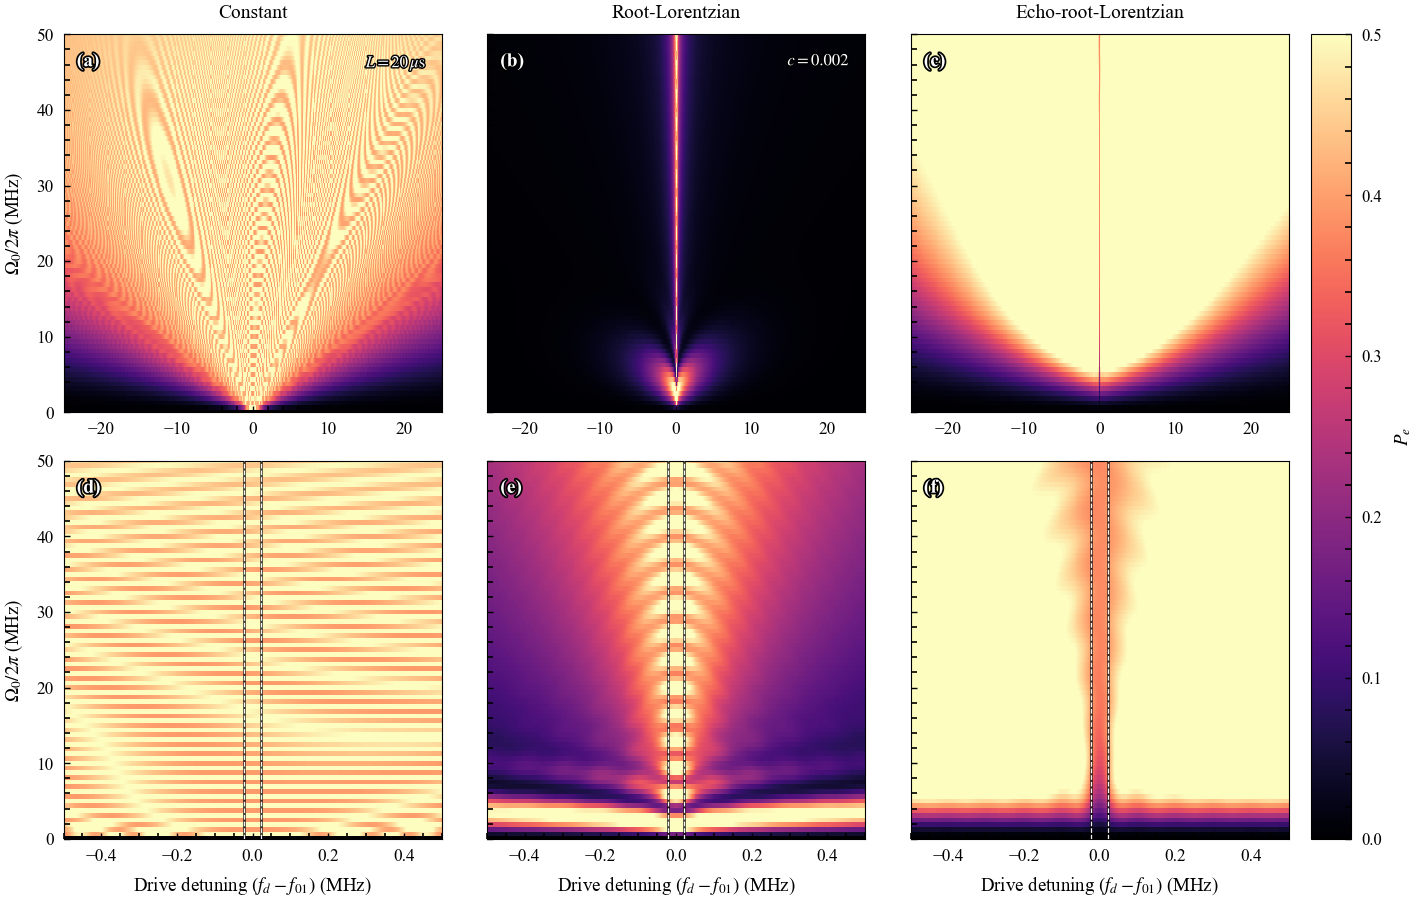

In [3]:
plt.rcParams.update({
    'figure.figsize': (7.1, 4.55),
    'axes.titlesize': 7.0,
    'axes.labelsize': 6.8,
    'xtick.labelsize': 6.2,
    'ytick.labelsize': 6.2,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

fig, axes = plt.subplots(2, 3, sharey=True, constrained_layout=True)
protocols = (
    ('constant', 'Constant'),
    ('lorentzian', 'Root-Lorentzian'),
    ('echo', 'Echo-root-Lorentzian'),
)
views = (
    ('Broad domain', BROAD_SPAN_MHZ, broad_detuning_mhz, broad_maps),
    ('Narrow domain', NARROW_SPAN_MHZ, narrow_detuning_mhz, narrow_maps),
)
panel_labels = iter('abcdef')
image = None

for row, (view_label, span_mhz, plot_detuning, plot_maps) in enumerate(views):
    for column, (protocol, protocol_label) in enumerate(protocols):
        ax = axes[row, column]
        plot_population = plot_maps[protocol]
        image = ax.pcolormesh(
            plot_detuning,
            rabi_mhz,
            plot_population,
            shading='auto',
            cmap='magma',
            vmin=0.0,
            vmax=0.5,
            rasterized=True,
        )
        ax.set_xlim(-span_mhz / 2, span_mhz / 2)
        ax.set_ylim(rabi_mhz.min(), rabi_mhz.max())
        ax.set_box_aspect(1.0)
        if row == 1:
            for t2_edge_mhz in (-t2_limit_fwhm_mhz / 2, t2_limit_fwhm_mhz / 2):
                ax.axvline(
                    t2_edge_mhz, color='black', lw=1.0, alpha=0.75, zorder=4,
                )
                ax.axvline(
                    t2_edge_mhz, color='white', lw=0.45, ls='--', alpha=0.95, zorder=5,
                )
        panel_text = ax.text(
            0.035, 0.95, f'({next(panel_labels)})',
            transform=ax.transAxes, ha='left', va='top',
            color='white', fontweight='bold',
        )
        panel_text.set_path_effects([path_effects.withStroke(linewidth=1.25, foreground='black')])
        if row == 0:
            ax.set_title(protocol_label)
        if row == 1:
            ax.set_xlabel(r'Drive detuning $(f_d-f_{01})$ (MHz)')
        if column == 0:
            ax.set_ylabel(r'$\Omega_0/2\pi$ (MHz)')

if image is None:
    raise RuntimeError('No panels were generated')
duration_text = axes[0, 0].text(
    0.96, 0.95, rf'$L={duration_us:g}\,\mu\mathrm{{s}}$',
    transform=axes[0, 0].transAxes, ha='right', va='top',
    color='white', fontsize=6.0,
)
duration_text.set_path_effects([path_effects.withStroke(linewidth=1.0, foreground='black')])
cutoff_text = axes[0, 1].text(
    0.96, 0.95, rf'$c={CUTOFF:g}$',
    transform=axes[0, 1].transAxes, ha='right', va='top',
    color='white', fontsize=6.0,
)
cutoff_text.set_path_effects([path_effects.withStroke(linewidth=1.0, foreground='black')])
colorbar = fig.colorbar(image, ax=axes, pad=0.018, fraction=0.05)
colorbar.set_label(r'$P_e$')
colorbar.ax.tick_params(labelsize=6.0)

saved = save_figure(
    fig,
    '02_central_spectroscopy',
    variant=VARIANT,
    formats=('pdf', 'png', 'svg'),
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.04,
)
saved

Selected peak-Rabi frequencies (MHz): [ 2.5 10.  40. ]


[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_lorentzian_echo_slices.pdf'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_lorentzian_echo_slices.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_lorentzian_echo_slices.svg')]

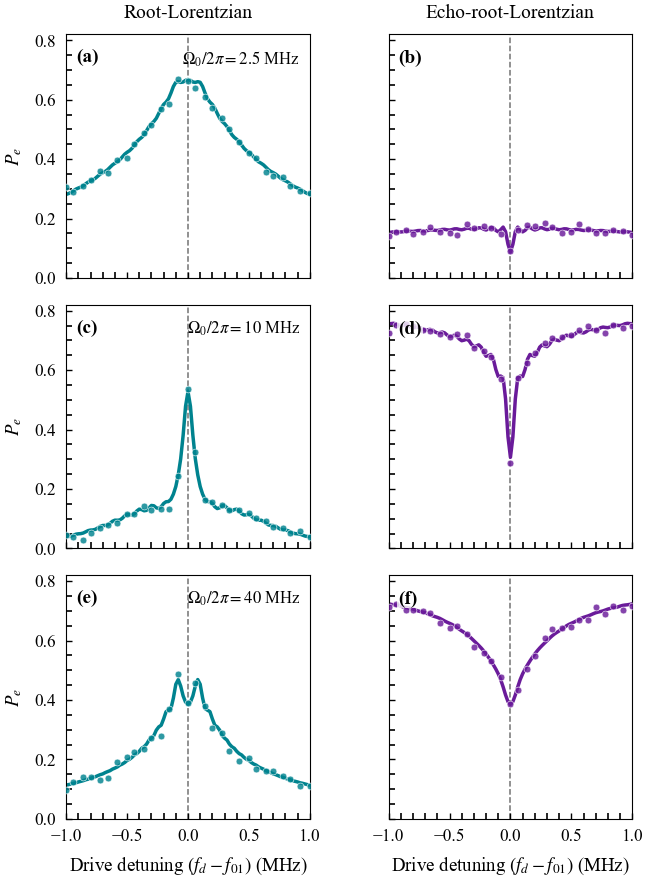

In [4]:
# Main-text Fig. 3: matched spectral slices at three drive amplitudes.
TARGET_SLICE_RABI_MHZ = np.asarray([2.5, 10.0, 40.0])
slice_indices = np.asarray([
    int(np.argmin(np.abs(rabi_mhz - target)))
    for target in TARGET_SLICE_RABI_MHZ
])
selected_slice_rabi_mhz = rabi_mhz[slice_indices]
np.testing.assert_allclose(selected_slice_rabi_mhz, TARGET_SLICE_RABI_MHZ)

slice_protocols = (
    ('lorentzian', 'Root-Lorentzian', '#00838f'),
    ('echo', 'Echo-root-Lorentzian', '#6a1b9a'),
)
fig_slices, slice_axes = plt.subplots(
    3, 2, figsize=(3.38, 4.45), sharex=True, sharey=True,
    constrained_layout=True,
)
slice_panel_labels = iter('abcdef')

# Draft-only placeholder points. Replace these arrays with measured linecuts
# before submission; the fixed seed keeps the manuscript reproducible.
DUMMY_SLICE_DATA_SEED = 3103
DUMMY_SLICE_DATA_POINTS = 29
DUMMY_SLICE_NOISE_STD = 0.012
dummy_slice_rng = np.random.default_rng(DUMMY_SLICE_DATA_SEED)
dummy_slice_indices = np.unique(np.linspace(
    0, len(detuning_mhz) - 1, DUMMY_SLICE_DATA_POINTS, dtype=int
))

for row, (amplitude_index, amplitude_mhz) in enumerate(
    zip(slice_indices, selected_slice_rabi_mhz)
):
    for column, (protocol, title, color) in enumerate(slice_protocols):
        ax = slice_axes[row, column]
        simulation_trace = archived_maps[protocol][amplitude_index]
        ax.plot(
            detuning_mhz, simulation_trace,
            color=color, lw=1.25,
        )
        dummy_trace = np.clip(
            simulation_trace[dummy_slice_indices]
            + dummy_slice_rng.normal(
                0.0, DUMMY_SLICE_NOISE_STD, dummy_slice_indices.size
            ),
            0.0, 0.82,
        )
        ax.scatter(
            detuning_mhz[dummy_slice_indices], dummy_trace,
            s=6.0, color=color, edgecolors='white', linewidths=0.25,
            alpha=0.82, zorder=3,
        )
        ax.axvline(0.0, color='0.45', lw=0.55, ls='--', zorder=0)
        ax.set_xlim(detuning_mhz.min(), detuning_mhz.max())
        ax.set_ylim(0.0, 0.82)
        ax.set_box_aspect(1.0)
        ax.text(
            0.04, 0.94, f'({next(slice_panel_labels)})',
            transform=ax.transAxes, ha='left', va='top',
            fontweight='bold',
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.78, 'pad': 0.5},
        )
        if row == 0:
            ax.set_title(title)
        if row == 2:
            ax.set_xlabel(r'Drive detuning $(f_d-f_{01})$ (MHz)')
        if column == 0:
            ax.set_ylabel(r'$P_e$')
            ax.text(
                0.96, 0.94, rf'$\Omega_0/2\pi={amplitude_mhz:g}$ MHz',
                transform=ax.transAxes, ha='right', va='top', fontsize=6.0,
            )

saved_slices = save_figure(
    fig_slices,
    '03_lorentzian_echo_slices',
    variant=VARIANT,
    formats=('pdf', 'png', 'svg'),
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.04,
)
print('Selected peak-Rabi frequencies (MHz):', selected_slice_rabi_mhz)
saved_slices

### Provenance

The Lorentzian maps and spectral slices are calculated with the identical Supplemental generator and parameter set. The broad calculation uses 6400 integration steps per pulse half for stability at $|\Delta|/2\pi=25$ MHz; the narrow calculation retains the archived 1600-step setting and is numerically verified against every overlapping point in the archived Supplemental arrays. The constant-pulse row is evaluated exactly from the time-independent affine Bloch generator using a batched matrix exponential. No interpolation, normalization, or independent color rescaling is applied. All protocols use the measurement-linked $T_1$ and conservative effective transverse-coherence parameters recorded in the archive.